### Comparison of ES GRPO

In [ ]:
import json
from pathlib import Path
from typing import Iterator, Dict, Any, Optional
import pandas as pd
BASE_DIR = Path("/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/PixArt/ES_vs_GRPO")

def param_norms_to_df(param_norms: dict) -> pd.DataFrame:
    """
    Flatten a nested param_norms dict into a tidy pandas DataFrame.
    Input format:
        {
            "param_name": {
                "delta_norm_sq": float,
                "shape": [int, ...],
                "numel": int,
                ... (other stats allowed)
            },
            ...
        }
    Returns a DataFrame with columns:
        - param_name
        - delta_norm_sq
        - numel
        - shape (as list)
        - shape_str (optional, human-readable "a x b x c")
        - plus any extra keys present in the inner dicts
    """
    rows = []
    for name, stats in param_norms.items():
        row = {"param_name": name}
        # Copy all scalar / list fields
        for k, v in stats.items():
            row[k] = v
        # Convenience: add a string representation of shape if present
        if "shape" in stats and isinstance(stats["shape"], (list, tuple)):
            row["shape_str"] = " x ".join(str(x) for x in stats["shape"])
        rows.append(row)
    df = pd.DataFrame(rows)
    # Optional: sort by delta_norm_sq descending if present
    if "delta_norm_sq" in df.columns:
        df = df.sort_values("delta_norm_sq", ascending=False).reset_index(drop=True)
    return df

 
def param_norms_list_to_df(param_norms_list):
    """
    param_norms_list: list of dicts, each like
        {
            "model.embed_tokens.weight": {
                "delta_norm_sq": ...,
                "shape": [...],
                "numel": ...,
                ...
            },
            "model.layers.0.self_attn.q_proj.weight": { ... },
            ...
        }

    Returns a DataFrame with columns:
        - step
        - param_name
        - delta_norm_sq
        - numel
        - shape (list)
        - shape_str (human-readable)
        - plus any other scalar fields in stats
    """
    rows = []

    for step_idx, param_dict in enumerate(param_norms_list):
        if not isinstance(param_dict, dict):
            continue  # skip weird entries

        for name, stats in param_dict.items():
            if not isinstance(stats, dict):
                continue

            row = {
                "step": step_idx,
                "param_name": name,
            }

            # copy all fields from stats
            for k, v in stats.items():
                row[k] = v

            # add shape_str for convenience
            shape = stats.get("shape")
            if isinstance(shape, (list, tuple)):
                row["shape_str"] = " x ".join(str(x) for x in shape)

            rows.append(row)

    df = pd.DataFrame(rows)

    if "delta_norm_sq" in df.columns:
        df = df.sort_values(["step", "delta_norm_sq"], ascending=[True, False]).reset_index(drop=True)

    return df


def iter_jsonl(path: Path, max_records: Optional[int] = None) -> Iterator[Dict[str, Any]]:
    """
    Stream a JSONL file line by line.

    Args:
        path: Path to the .jsonl file.
        max_records: If not None, stop after yielding this many records.

    Yields:
        Parsed JSON objects (dicts).
    """
    count = 0
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError as e:
                # You can add logging here if needed
                print(f"Skipping malformed line {count}: {e}")
                continue

            yield obj
            count += 1
            if max_records is not None and count >= max_records:
                break


def load_sample_as_dataframe(
    filename: str,
    max_records: int = 10_000,
) -> pd.DataFrame:
    """
    Load up to `max_records` rows from a JSONL file into a pandas DataFrame.

    Args:
        filename: Name of the JSONL file (e.g. 'es_param_norms.jsonl').
        max_records: Maximum number of lines/records to load.

    Returns:
        pandas.DataFrame with one row per JSON line.
    """
    path = BASE_DIR / filename
    records = list(iter_jsonl(path, max_records=max_records))
    df = pd.DataFrame.from_records(records)
    return df


if __name__ == "__main__":
    # Example: peek at the first few records structurally
    es_path = BASE_DIR / "es_param_norms.jsonl"
    grpo_path = BASE_DIR / "grpo_param_norms.jsonl"

    print("First ES record:")
    for i, rec in enumerate(iter_jsonl(es_path, max_records=1)):
        print(rec)
    print()

    print("First GRPO record:")
    for i, rec in enumerate(iter_jsonl(grpo_path, max_records=1)):
        print(rec)
    print()

    # Example: load a sample into DataFrames
    es_df = load_sample_as_dataframe("es_param_norms.jsonl", max_records=5000)
    grpo_df = load_sample_as_dataframe("grpo_param_norms.jsonl", max_records=5000)

    print("ES columns:", es_df.columns.tolist())
    print("GRPO columns:", grpo_df.columns.tolist())

    # Quick sanity checks
    print("ES sample head:")
    print(es_df.head())

    print("GRPO sample head:")
    print(grpo_df.head())

First ES record:
{'step': 1, 'forward_passes': 6000, 'reward': 0.22216666666666668, 'fitness_mean': 0.22216666666666668, 'fitness_std': 0.08463335959038584, 'param_norms': [{'model.embed_tokens.weight': {'delta_norm_sq': 7.288728713989258, 'shape': [151936, 2560], 'numel': 388956160}, 'model.layers.0.self_attn.qkv_proj.weight': {'delta_norm_sq': 0.29155004024505615, 'shape': [6144, 2560], 'numel': 15728640}, 'model.layers.0.self_attn.o_proj.weight': {'delta_norm_sq': 0.19950056076049805, 'shape': [2560, 4096], 'numel': 10485760}, 'model.layers.0.self_attn.q_norm.weight': {'delta_norm_sq': 8.66129994392395e-08, 'shape': [128], 'numel': 128}, 'model.layers.0.self_attn.k_norm.weight': {'delta_norm_sq': 0.0, 'shape': [128], 'numel': 128}, 'model.layers.0.mlp.gate_up_proj.weight': {'delta_norm_sq': 0.9245408773422241, 'shape': [19456, 2560], 'numel': 49807360}, 'model.layers.0.mlp.down_proj.weight': {'delta_norm_sq': 0.4620603919029236, 'shape': [2560, 9728], 'numel': 24903680}, 'model.laye

### Reward trajectory inspection

<Axes: xlabel='step', ylabel='reward'>

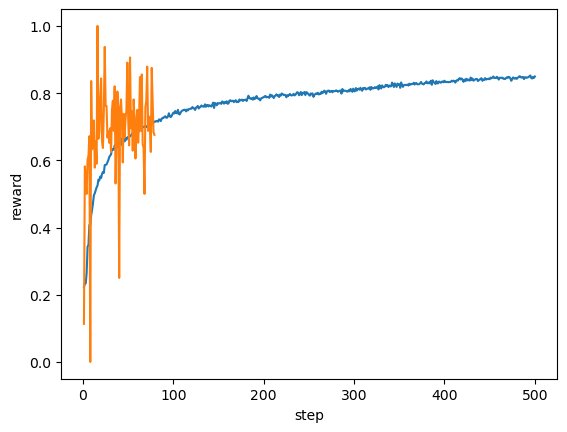

In [2]:
import seaborn as sns
sns.lineplot(data=es_df, x="step", y="reward", )
sns.lineplot(data=grpo_df, x="step", y="reward", )

<Axes: xlabel='step', ylabel='fitness_std'>

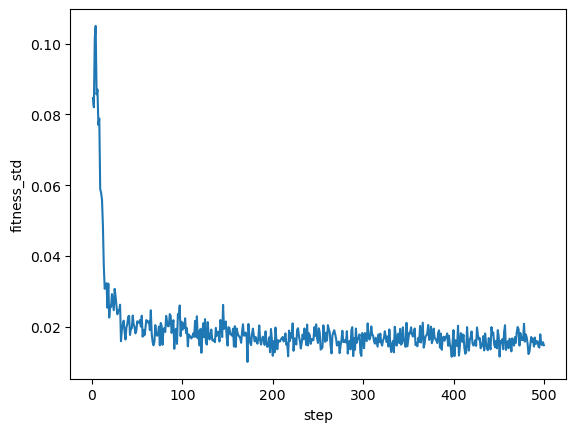

In [5]:
sns.lineplot(
    data=es_df,
    x="step",
    y="fitness_std",
)

<Axes: xlabel='step', ylabel='fitness_mean'>

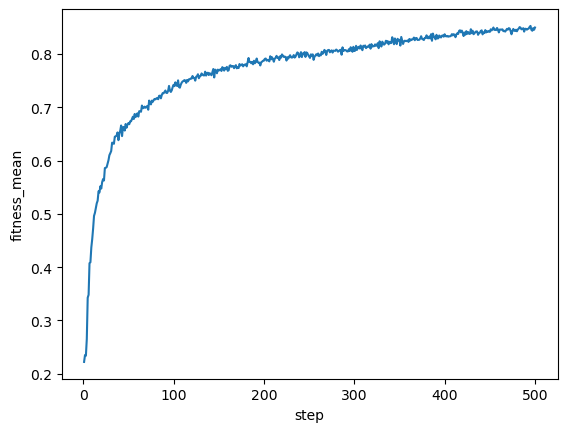

In [4]:
def fitness_std_error(series):
    if "fitness_std" in es_df.columns:
        return es_df.loc[series.index, "fitness_std"].values
    else:
        return None

sns.lineplot(
    data=es_df,
    x="step",
    y="fitness_mean",
    errorbar=fitness_std_error if "fitness_std" in es_df.columns else None
)


### param norm processing

In [7]:
import json
from pathlib import Path
from typing import Dict, Any

def load_first_param_norms_record(path: str) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            return rec  # first record only
    raise RuntimeError("File empty or no valid JSON lines.")


jsonl_path = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/PixArt/ES_vs_GRPO/es_param_norms.jsonl"
record = load_first_param_norms_record(jsonl_path)

param_norms = record["param_norms"]
df = param_norms_list_to_df(param_norms)

print(df.head())

   step                               param_name  delta_norm_sq  \
0     0                model.embed_tokens.weight       7.288729   
1     0  model.layers.21.mlp.gate_up_proj.weight       0.931283   
2     0  model.layers.20.mlp.gate_up_proj.weight       0.928670   
3     0  model.layers.19.mlp.gate_up_proj.weight       0.928487   
4     0   model.layers.2.mlp.gate_up_proj.weight       0.927889   

            shape      numel      shape_str  
0  [151936, 2560]  388956160  151936 x 2560  
1   [19456, 2560]   49807360   19456 x 2560  
2   [19456, 2560]   49807360   19456 x 2560  
3   [19456, 2560]   49807360   19456 x 2560  
4   [19456, 2560]   49807360   19456 x 2560  


In [ ]:
es_path = BASE_DIR / "es_param_norms.jsonl"
grpo_path = BASE_DIR / "grpo_param_norms.jsonl"

print("First ES record:")
for i, rec in enumerate(iter_jsonl(es_path, max_records=1)):
    print(rec)
print()

print("First GRPO record:")
for i, rec in enumerate(iter_jsonl(grpo_path, max_records=1)):
    print(rec)
print()

# Example: load a sample into DataFrames
es_df = load_sample_as_dataframe("es_param_norms.jsonl", max_records=10000)
grpo_df = load_sample_as_dataframe("grpo_param_norms.jsonl", max_records=10000)

In [20]:
param_norms_list_to_df(es_df.iloc[499]['param_norms'])

,step,param_name,delta_norm_sq,shape,numel,shape_str
0,0,model.embed_tokens.weight,3.551913e+03,"[151936, 2560]",388956160,151936 x 2560
1,0,model.layers.21.mlp.gate_up_proj.weight,4.522439e+02,"[19456, 2560]",49807360,19456 x 2560
2,0,model.layers.20.mlp.gate_up_proj.weight,4.508594e+02,"[19456, 2560]",49807360,19456 x 2560
3,0,model.layers.19.mlp.gate_up_proj.weight,4.505993e+02,"[19456, 2560]",49807360,19456 x 2560
4,0,model.layers.0.mlp.gate_up_proj.weight,4.502224e+02,"[19456, 2560]",49807360,19456 x 2560
...,...,...,...,...,...,...
285,0,model.layers.20.self_attn.k_norm.weight,8.871221e-04,[128],128,128
286,0,model.layers.32.input_layernorm.weight,8.544922e-04,[2560],2560,2560
287,0,model.layers.5.self_attn.k_norm.weight,5.177662e-04,[128],128,128
288,0,model.layers.35.input_layernorm.weight,9.536743e-07,[2560],2560,2560


In [49]:
from collections import defaultdict
import numpy as np
from sklearn.linear_model import LinearRegression

# Collect per-parameter delta_norm_sq trajectories across all rows
param_delta_dict = defaultdict(list)  # param_name -> list of (step, delta_norm_sq)

for idx, row in es_df.iterrows():
    step = row['step']
    norms = param_norms_list_to_df(row['param_norms'])
    for _, entry in norms.iterrows():
        param_name = entry['param_name']
        delta_norm_sq = entry['delta_norm_sq']
        param_delta_dict[param_name].append((step, delta_norm_sq))

# For each param, fit a no-bias linear regression over (step, delta_norm_sq)
slope_records = []
for param_name, data in param_delta_dict.items():
    data = sorted(data)  # ensure steps are ordered
    steps, delta_norms = zip(*data)
    steps = np.array(steps).reshape(-1, 1)
    delta_norms = np.array(delta_norms)
    reg = LinearRegression(fit_intercept=False)
    reg.fit(steps, delta_norms)
    slope = reg.coef_[0]
    # Compute R^2 goodness of fit
    y_pred = reg.predict(steps)
    ss_res = ((delta_norms - y_pred) ** 2).sum()
    ss_tot = ((delta_norms - delta_norms.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else float('nan')
    slope_records.append({
        "param_name": param_name,
        "slope": slope,
        "r2": r2,
    })

# Make full result as a DataFrame with param_name, slope, r2 columns
param_slopes = pd.DataFrame(slope_records).set_index("param_name")

# Print a few example rows
print(param_slopes.head(10))


                                            slope        r2
param_name                                                 
model.embed_tokens.weight                7.136429  0.999899
model.layers.21.mlp.gate_up_proj.weight  0.908635  0.999897
model.layers.20.mlp.gate_up_proj.weight  0.905815  0.999892
model.layers.19.mlp.gate_up_proj.weight  0.905305  0.999892
model.layers.2.mlp.gate_up_proj.weight   0.900811  0.999815
model.layers.18.mlp.gate_up_proj.weight  0.904065  0.999892
model.layers.1.mlp.gate_up_proj.weight   0.896377  0.999813
model.layers.22.mlp.gate_up_proj.weight  0.902149  0.999892
model.layers.15.mlp.gate_up_proj.weight  0.902641  0.999891
model.layers.17.mlp.gate_up_proj.weight  0.902353  0.999895


In [50]:
ref_param_info = param_norms_list_to_df(es_df.iloc[499]['param_norms'])
ref_param_info.drop(columns=['delta_norm_sq'], inplace=True)
ref_param_info_slope = ref_param_info.merge(param_slopes, left_on='param_name', right_index=True)

In [52]:
ref_param_info_slope

,step,param_name,shape,numel,shape_str,slope,r2
0,0,model.embed_tokens.weight,"[151936, 2560]",388956160,151936 x 2560,7.136429e+00,0.999899
1,0,model.layers.21.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.086350e-01,0.999897
2,0,model.layers.20.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.058154e-01,0.999892
3,0,model.layers.19.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.053047e-01,0.999892
4,0,model.layers.0.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.044320e-01,0.999900
...,...,...,...,...,...,...,...
285,0,model.layers.20.self_attn.k_norm.weight,[128],128,128,2.383668e-06,0.628845
286,0,model.layers.32.input_layernorm.weight,[2560],2560,2560,2.041543e-06,0.646545
287,0,model.layers.5.self_attn.k_norm.weight,[128],128,128,1.477938e-06,-0.037585
288,0,model.layers.35.input_layernorm.weight,[2560],2560,2560,2.844587e-09,-1.972208


$$\mathbb{E}\|\bar{\Delta\theta_{T}}\|^{2}=\frac{\sigma^{2}Td}{4N}$$

In [53]:
sigma = 0.0015
N = 30
ref_param_info_slope["d_randwalk"] = ref_param_info_slope["slope"] / sigma**2 * 4 * N
ref_param_info_slope["d_ratio"] = ref_param_info_slope["d_randwalk"] / ref_param_info_slope["numel"]
ref_param_info_slope["1-d_ratio"] = 1 - ref_param_info_slope["d_ratio"]

In [66]:
ref_param_info_slope

,step,param_name,shape,numel,shape_str,slope,r2,d_randwalk,d_ratio,1-d_ratio
0,0,model.embed_tokens.weight,"[151936, 2560]",388956160,151936 x 2560,7.136429e+00,0.999899,3.806095e+08,0.978541,0.021459
1,0,model.layers.21.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.086350e-01,0.999897,4.846053e+07,0.972959,0.027041
2,0,model.layers.20.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.058154e-01,0.999892,4.831016e+07,0.969940,0.030060
3,0,model.layers.19.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.053047e-01,0.999892,4.828291e+07,0.969393,0.030607
4,0,model.layers.0.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.044320e-01,0.999900,4.823637e+07,0.968459,0.031541
...,...,...,...,...,...,...,...,...,...,...
285,0,model.layers.20.self_attn.k_norm.weight,[128],128,128,2.383668e-06,0.628845,1.271289e+02,0.993195,0.006805
286,0,model.layers.32.input_layernorm.weight,[2560],2560,2560,2.041543e-06,0.646545,1.088823e+02,0.042532,0.957468
287,0,model.layers.5.self_attn.k_norm.weight,[128],128,128,1.477938e-06,-0.037585,7.882335e+01,0.615807,0.384193
288,0,model.layers.35.input_layernorm.weight,[2560],2560,2560,2.844587e-09,-1.972208,1.517113e-01,0.000059,0.999941


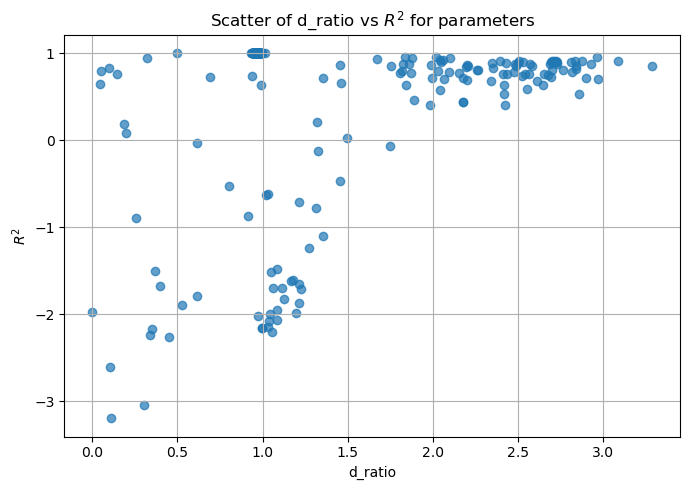

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(ref_param_info_slope["d_ratio"], ref_param_info_slope["r2"], alpha=0.7)
plt.xlabel("d_ratio")
plt.ylabel("$R^2$")
plt.title("Scatter of d_ratio vs $R^2$ for parameters")
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
ref_param_info_slope

,step,param_name,shape,numel,shape_str,slope,d_randwalk,d_ratio
0,0,model.embed_tokens.weight,"[151936, 2560]",388956160,151936 x 2560,7.136429e+00,3.806095e+08,0.978541
1,0,model.layers.21.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.086350e-01,4.846053e+07,0.972959
2,0,model.layers.20.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.058154e-01,4.831016e+07,0.969940
3,0,model.layers.19.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.053047e-01,4.828291e+07,0.969393
4,0,model.layers.0.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.044320e-01,4.823637e+07,0.968459
...,...,...,...,...,...,...,...,...
285,0,model.layers.20.self_attn.k_norm.weight,[128],128,128,2.383668e-06,1.271289e+02,0.993195
286,0,model.layers.32.input_layernorm.weight,[2560],2560,2560,2.041543e-06,1.088823e+02,0.042532
287,0,model.layers.5.self_attn.k_norm.weight,[128],128,128,1.477938e-06,7.882335e+01,0.615807
288,0,model.layers.35.input_layernorm.weight,[2560],2560,2560,2.844587e-09,1.517113e-01,0.000059


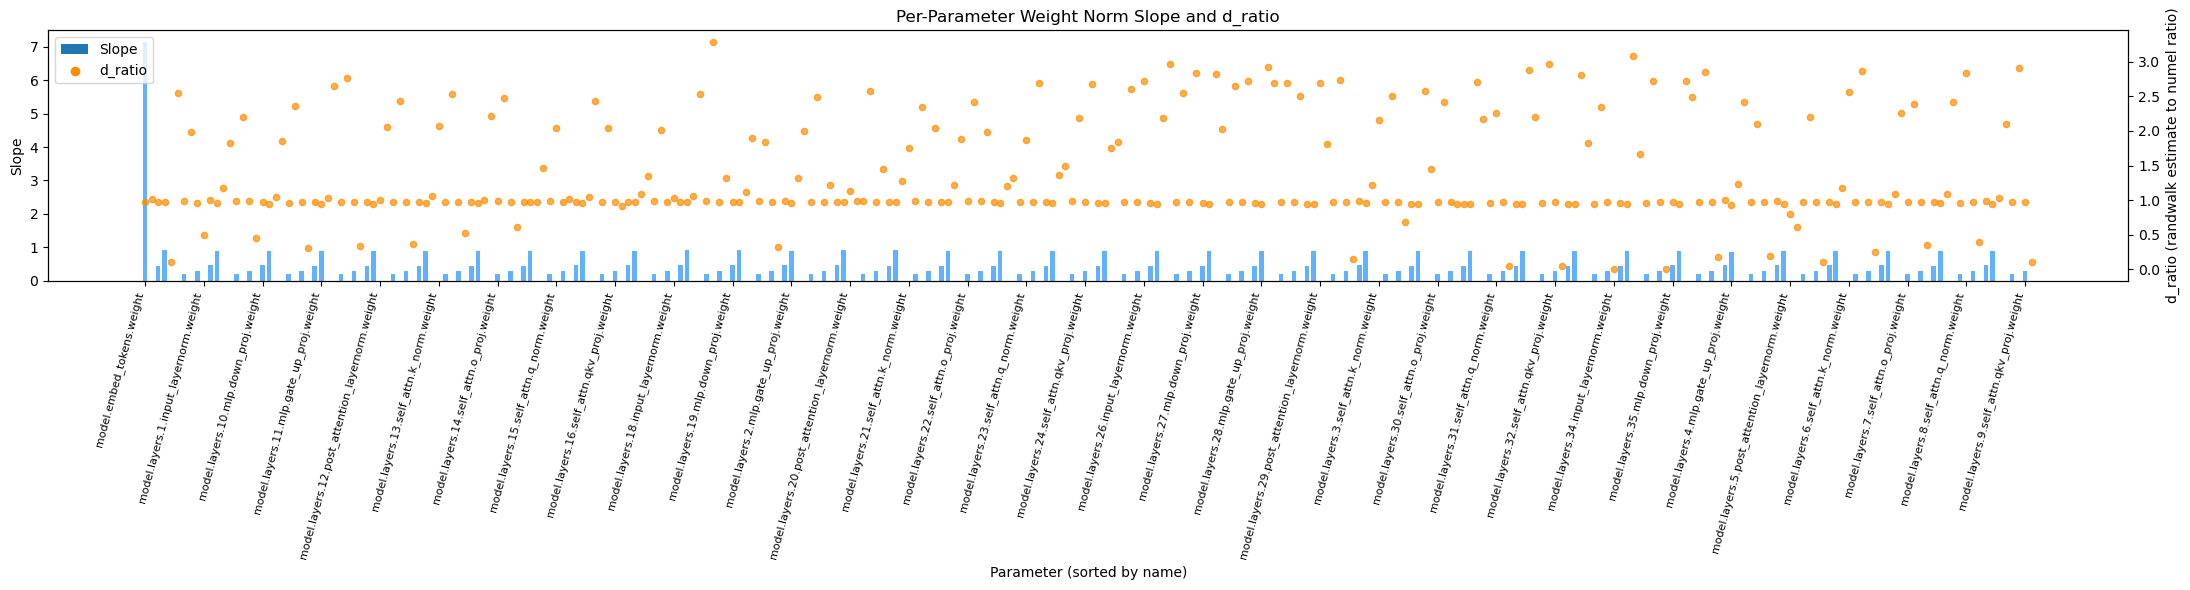

In [34]:
import matplotlib.pyplot as plt

# Sort by param_name for consistent visualization
df_sorted = ref_param_info_slope.sort_values("param_name")

# Large figure for all params, param_name on x axis
fig, ax1 = plt.subplots(figsize=(22, 6))

# Let's plot slope as a bar (blue) and overlay d_ratio as a scatter (orange), sharing x axis
x = range(len(df_sorted))
ax1.bar(x, df_sorted["slope"], width=0.7, label="Slope ($\Delta\|W\|^2 / \Delta$step)", color="dodgerblue", alpha=0.7)
ax1.set_ylabel("Slope")
ax1.set_xlabel("Parameter (sorted by name)")
ax1.set_title("Per-Parameter Weight Norm Slope and d_ratio")

ax2 = ax1.twinx()
ax2.scatter(x, df_sorted["d_ratio"], s=20, color="darkorange", label="d_ratio", alpha=0.7, marker="o")
ax2.set_ylabel("d_ratio (randwalk estimate to numel ratio)")

# Add param names sparsely as x-tick labels for readability (show every N-th param)
N = max(1, len(df_sorted) // 30)
label_pos = list(range(0, len(df_sorted), N))
ax1.set_xticks(label_pos)
ax1.set_xticklabels(df_sorted["param_name"].iloc[label_pos], rotation=75, ha='right', fontsize=8)

# Legends
ln1 = ax1.bar([], [], color="dodgerblue", alpha=0.7, label="Slope")
ln2 = ax2.scatter([], [], color="darkorange", label="d_ratio")
handles = [ln1, ln2]
labs = [h.get_label() for h in handles]
ax1.legend(handles, labs, loc="upper left")

plt.tight_layout()
plt.show()

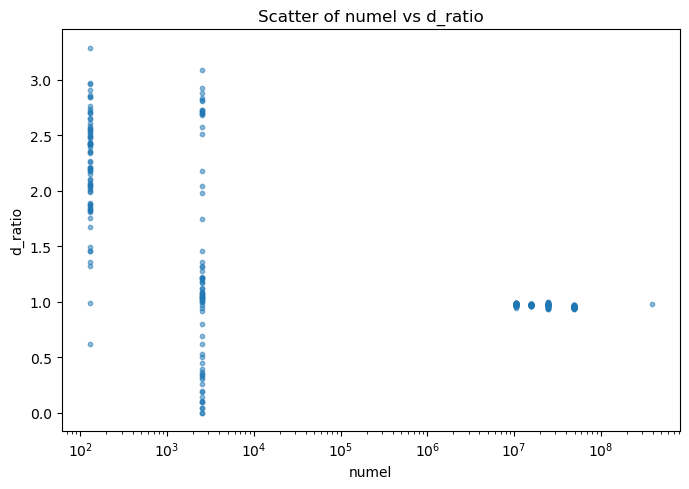

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(ref_param_info_slope["numel"], ref_param_info_slope["d_ratio"], s=10, alpha=0.5)
plt.xlabel("numel")
plt.ylabel("d_ratio")
plt.title("Scatter of numel vs d_ratio")
plt.xscale("log")
plt.tight_layout()
plt.show()

In [90]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def add_layer_and_kind_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    From a column 'param_name' like:
      - 'model.layers.21.mlp.gate_up_proj.weight'
      - 'model.layers.0.self_attn.q_proj.weight'
      - 'model.embed_tokens.weight'  (no layer index)
    extract:
      - 'layer' (int or -1 if no layer)
      - 'kind' (string grouping by submodule, e.g. 'mlp.gate_up_proj.weight')
    """
    def _parse(name: str):
        # Try to find ".layers.<idx>."
        m = re.search(r"\.layers\.(\d+)\.(.+)", name)
        if m:
            layer = int(m.group(1))
            kind = m.group(2)
        else:
            layer = -1
            # everything after "model." if present
            if name.startswith("model."):
                kind = name[len("model."):]
            else:
                kind = name
        return layer, kind

    layer_list = []
    kind_list = []
    for n in df["param_name"]:
        layer, kind = _parse(n)
        layer_list.append(layer)
        kind_list.append(kind)

    df = df.copy()
    df["layer"] = layer_list
    df["kind"] = kind_list
    return df


def plot_param_heatmap(
    df: pd.DataFrame,
    value_col: str = "slope",
    step: int = 0,
    include_nonlayer: bool = False,
    cmap: str = "viridis",
    figsize=(12, 6),
    vmin=None,
    vmax=None,
):
    """
    Plot a heatmap with:
      - rows = parameter 'kind' (e.g. 'mlp.gate_up_proj.weight')
      - columns = layer index
      - cell values = `value_col` (e.g. 'slope', 'd_randwalk', or 'd_ratio')

    Args:
        df: DataFrame with at least ['step', 'param_name', value_col].
        value_col: Metric to visualize ('slope', 'd_randwalk', 'd_ratio', ...).
        step: Filter to this step.
        include_nonlayer: If False, drop entries with layer == -1 (e.g. embed tokens).
        cmap: Matplotlib colormap name.
        figsize: Figure size.
        vmin, vmax: Optional color scale limits.
    """
    # Ensure layer/kind columns exist
    if "layer" not in df.columns or "kind" not in df.columns:
        df = add_layer_and_kind_columns(df)
    if "step" in df.columns:
        df_step = df[df["step"] == step].copy()
    else:
        df_step = df.copy()

    if not include_nonlayer:
        df_step = df_step[df_step["layer"] >= 0]

    if df_step.empty:
        if "step" in df.columns:
            raise ValueError(f"No data for step={step} after filtering.")
        else:
            raise ValueError("No data after filtering (and no 'step' column present).")

    # Build pivot: rows = kind, cols = layer
    pivot = df_step.pivot_table(
        index="kind",
        columns="layer",
        values=value_col,
        aggfunc="mean",  # in case multiple params map to same (kind, layer)
    )

    # Optional: sort columns and index
    pivot = pivot.sort_index(axis=1)  # sort layers
    pivot = pivot.sort_index(axis=0)  # sort kinds alphabetically

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        pivot,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        annot=False,
        cbar_kws={"label": value_col},
    )
    ax.set_xlabel("Layer")
    ax.set_ylabel("Parameter kind")
    ax.set_title(f"{value_col} heatmap by layer and param kind" + (f" (step={step})" if "step" in df.columns else ""))
    plt.tight_layout()
    plt.show()
    
    

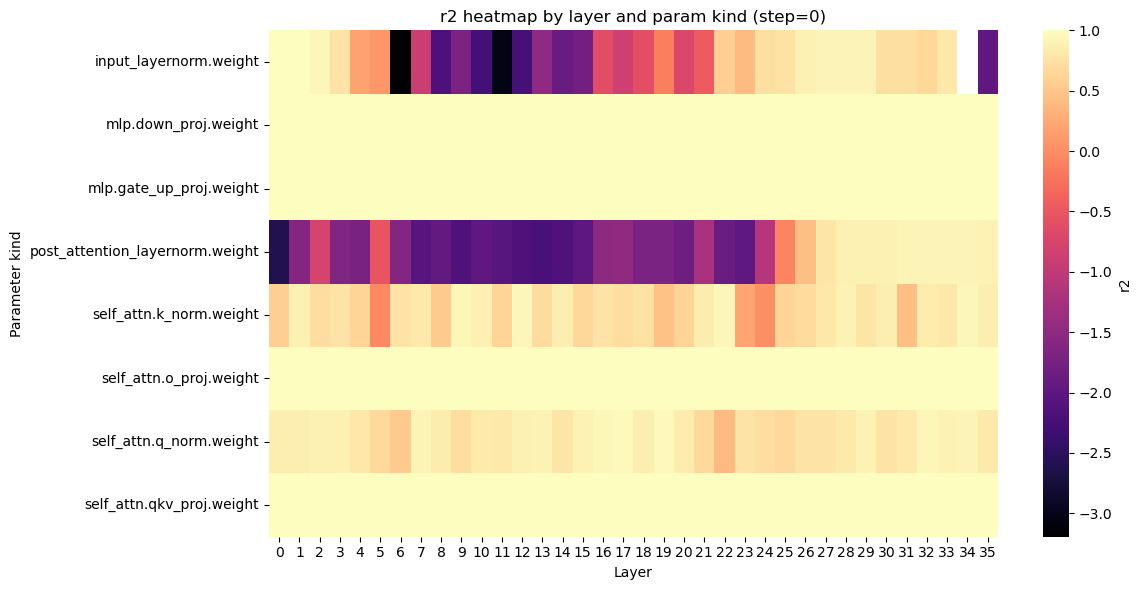

In [68]:
df_param_norms = add_layer_and_kind_columns(ref_param_info_slope)
plot_param_heatmap(df_param_norms, value_col="r2", step=0, cmap="magma",vmax=1)

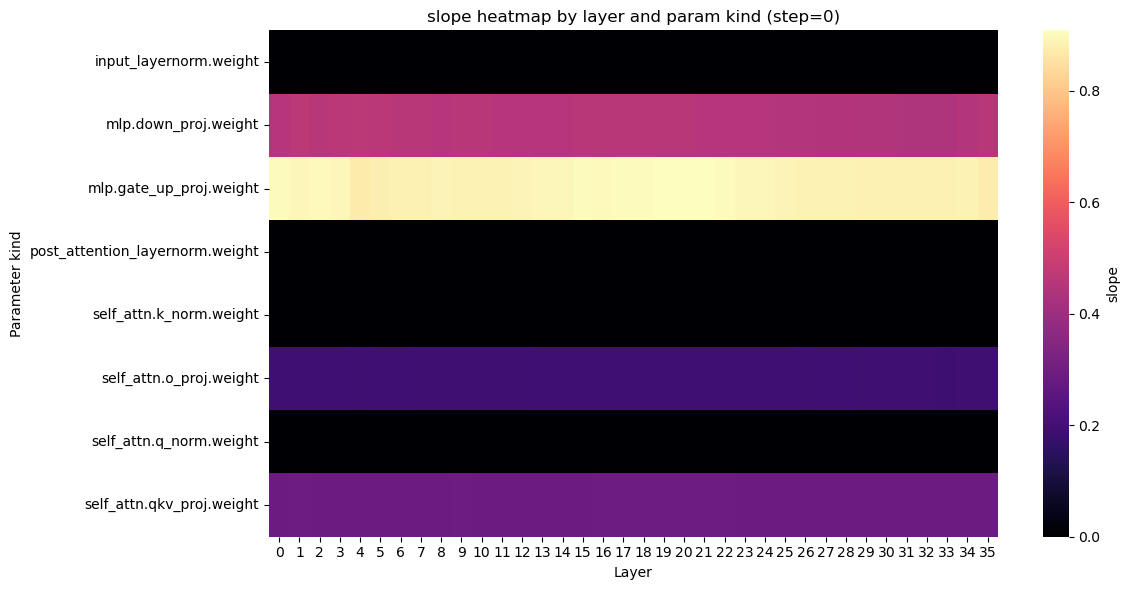

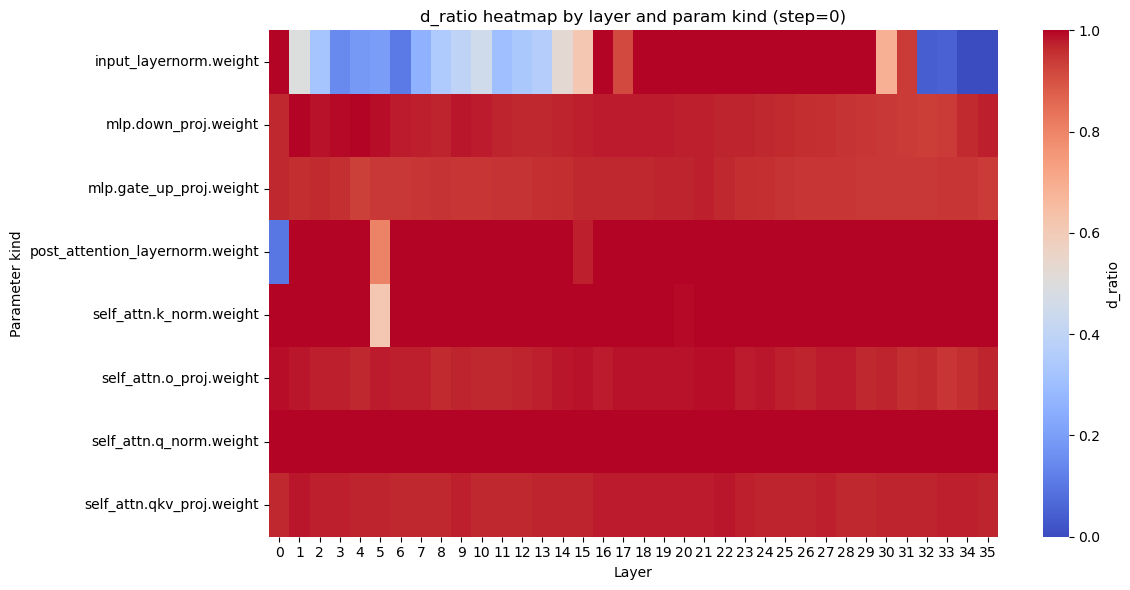

In [46]:

# Assuming df_param_norms is your DataFrame
df_param_norms = add_layer_and_kind_columns(ref_param_info_slope)

# Heatmap of slope
plot_param_heatmap(df_param_norms, value_col="slope", step=0, cmap="magma")

# Heatmap of d_ratio
plot_param_heatmap(df_param_norms, value_col="d_ratio", step=0, cmap="coolwarm", vmin=0, vmax=1)

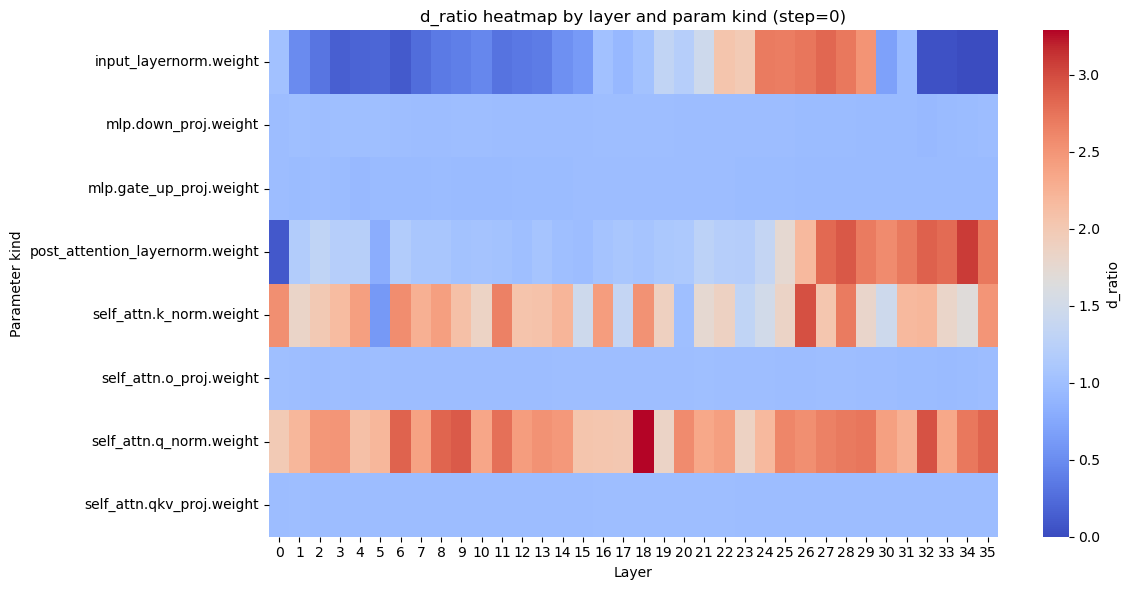

In [48]:
plot_param_heatmap(df_param_norms, value_col="d_ratio", step=0, cmap="coolwarm", )

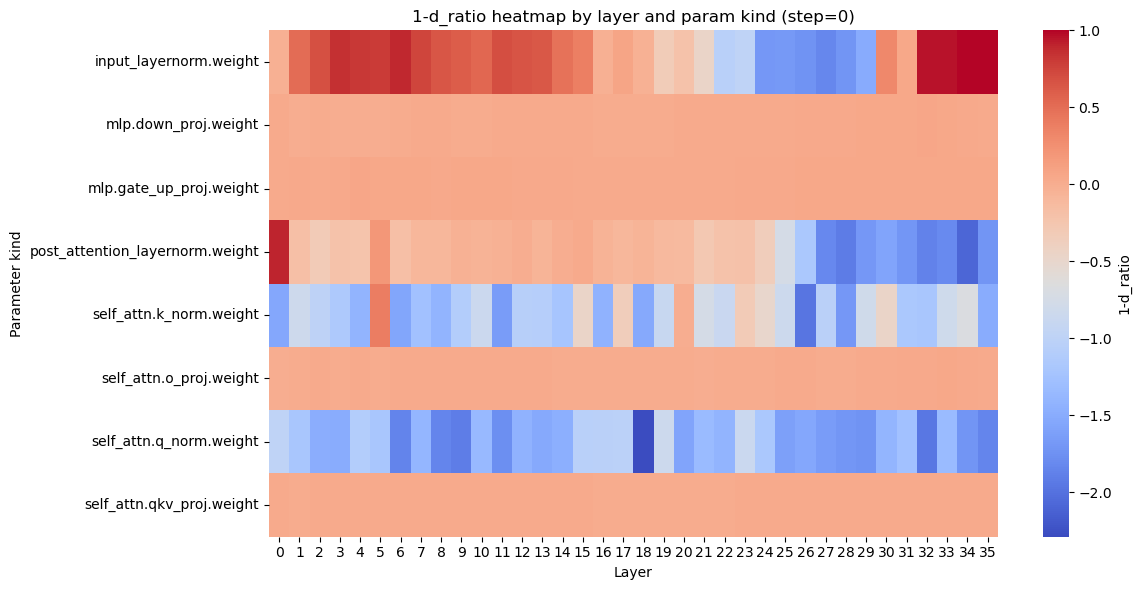

In [47]:
plot_param_heatmap(df_param_norms, value_col="1-d_ratio", cmap="coolwarm", )

In [58]:

df_param_norms = add_layer_and_kind_columns(ref_param_info_slope)

In [59]:
df_param_norms

,step,param_name,shape,numel,shape_str,slope,r2,d_randwalk,d_ratio,1-d_ratio,layer,kind
0,0,model.embed_tokens.weight,"[151936, 2560]",388956160,151936 x 2560,7.136429e+00,0.999899,3.806095e+08,0.978541,0.021459,-1,embed_tokens.weight
1,0,model.layers.21.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.086350e-01,0.999897,4.846053e+07,0.972959,0.027041,21,mlp.gate_up_proj.weight
2,0,model.layers.20.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.058154e-01,0.999892,4.831016e+07,0.969940,0.030060,20,mlp.gate_up_proj.weight
3,0,model.layers.19.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.053047e-01,0.999892,4.828291e+07,0.969393,0.030607,19,mlp.gate_up_proj.weight
4,0,model.layers.0.mlp.gate_up_proj.weight,"[19456, 2560]",49807360,19456 x 2560,9.044320e-01,0.999900,4.823637e+07,0.968459,0.031541,0,mlp.gate_up_proj.weight
...,...,...,...,...,...,...,...,...,...,...,...,...
285,0,model.layers.20.self_attn.k_norm.weight,[128],128,128,2.383668e-06,0.628845,1.271289e+02,0.993195,0.006805,20,self_attn.k_norm.weight
286,0,model.layers.32.input_layernorm.weight,[2560],2560,2560,2.041543e-06,0.646545,1.088823e+02,0.042532,0.957468,32,input_layernorm.weight
287,0,model.layers.5.self_attn.k_norm.weight,[128],128,128,1.477938e-06,-0.037585,7.882335e+01,0.615807,0.384193,5,self_attn.k_norm.weight
288,0,model.layers.35.input_layernorm.weight,[2560],2560,2560,2.844587e-09,-1.972208,1.517113e-01,0.000059,0.999941,35,input_layernorm.weight


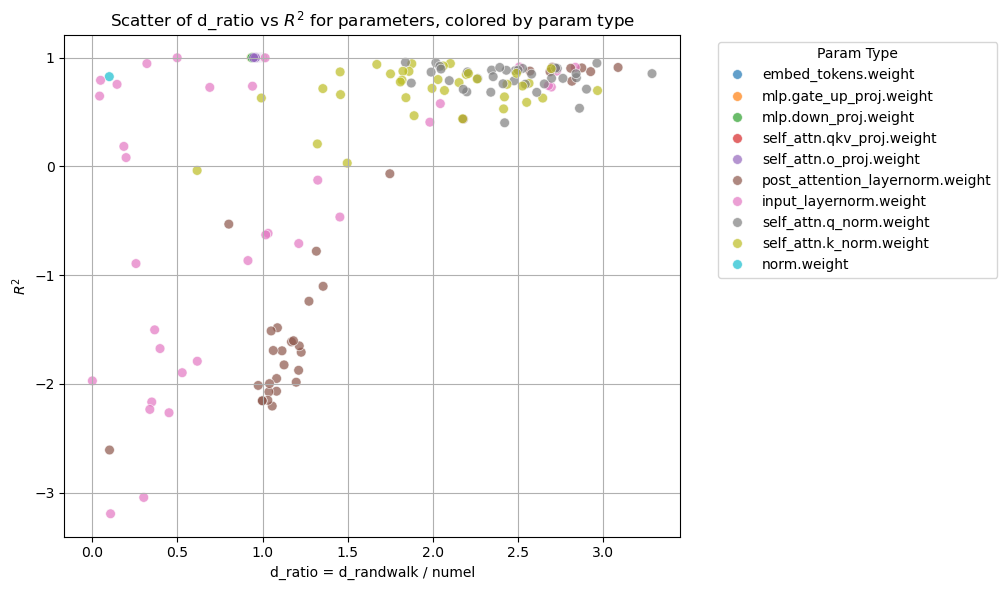

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

df_param_norms = add_layer_and_kind_columns(ref_param_info_slope)
plt.figure(figsize=(7, 6))
scatter = sns.scatterplot(
    data=df_param_norms,
    x="d_ratio",
    y="r2",
    hue="kind",   # assumes column from add_layer_and_kind_columns
    alpha=0.7,
    palette="tab10",
    s=49
)
plt.xlabel("d_ratio = d_randwalk / numel")
plt.ylabel("$R^2$")
plt.title("Scatter of d_ratio vs $R^2$ for parameters, colored by param type")
plt.grid(True)
plt.tight_layout()
plt.legend(title="Param Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Parameter scale vs random walk linearity

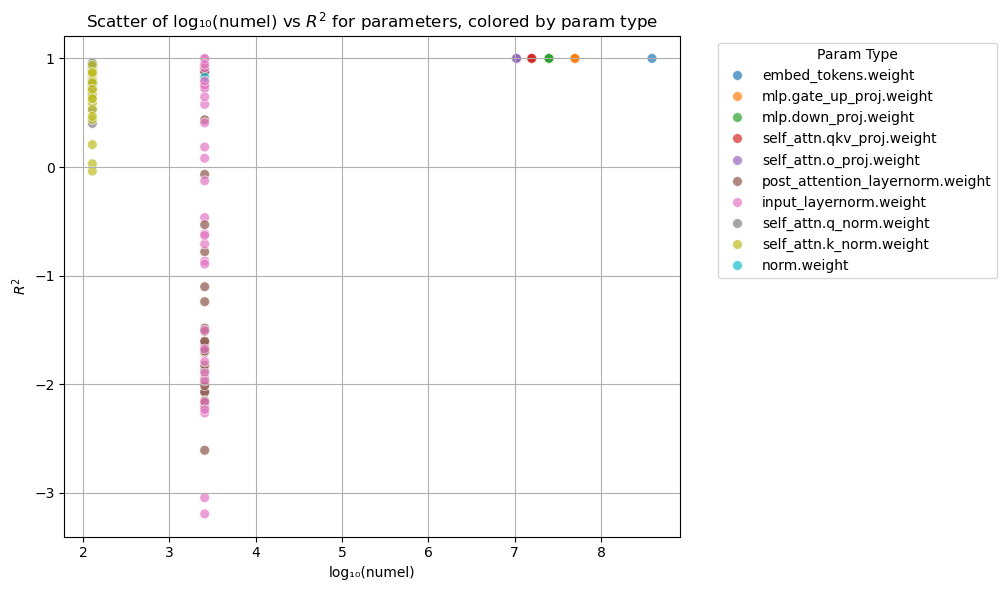

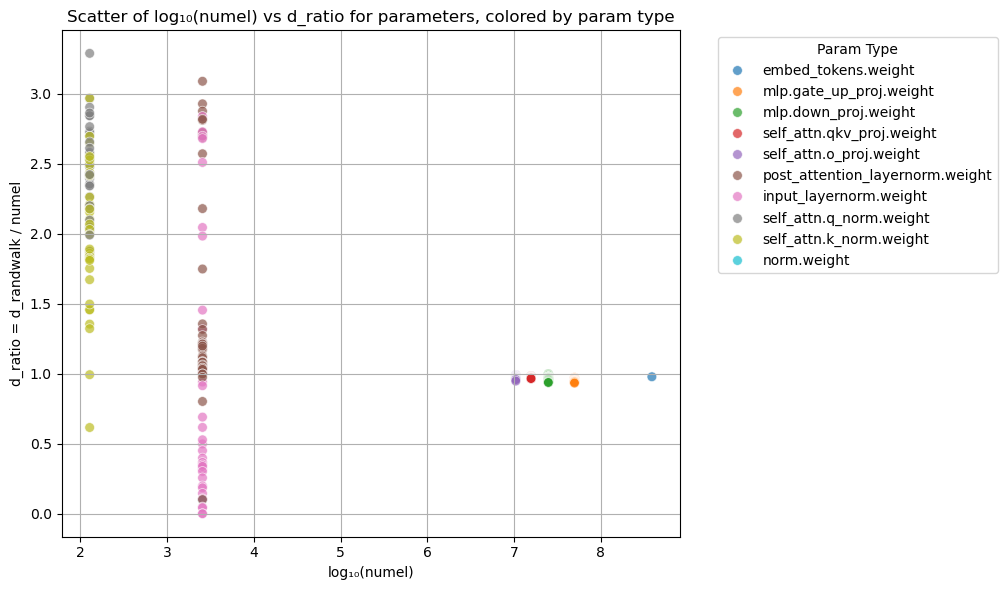

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_param_norms = add_layer_and_kind_columns(ref_param_info_slope)

# log(numel) vs R^2
plt.figure(figsize=(7, 6))
scatter = sns.scatterplot(
    data=df_param_norms,
    x=np.log10(df_param_norms["numel"].replace(0, np.nan)),  # avoid log(0)
    y="r2",
    hue="kind",
    alpha=0.7,
    palette="tab10",
    s=49
)
plt.xlabel("log₁₀(numel)")
plt.ylabel("$R^2$")
plt.title("Scatter of log₁₀(numel) vs $R^2$ for parameters, colored by param type")
plt.grid(True)
plt.tight_layout()
plt.legend(title="Param Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# log(numel) vs d_ratio
plt.figure(figsize=(7, 6))
scatter = sns.scatterplot(
    data=df_param_norms,
    x=np.log10(df_param_norms["numel"].replace(0, np.nan)),
    y="d_ratio",
    hue="kind",
    alpha=0.7,
    palette="tab10",
    s=49
)
plt.xlabel("log₁₀(numel)")
plt.ylabel("d_ratio = d_randwalk / numel")
plt.title("Scatter of log₁₀(numel) vs d_ratio for parameters, colored by param type")
plt.grid(True)
plt.tight_layout()
plt.legend(title="Param Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

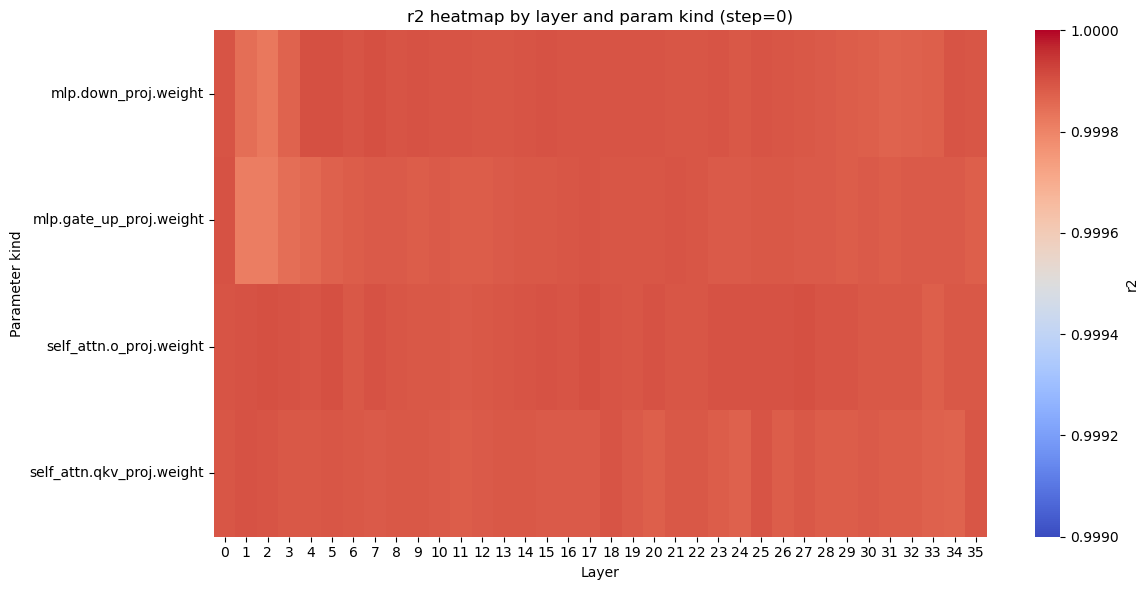

In [75]:
plot_param_heatmap(df_param_norms.query("numel > 10E6"), value_col="r2", cmap="coolwarm", vmax=1, vmin=0.9990)

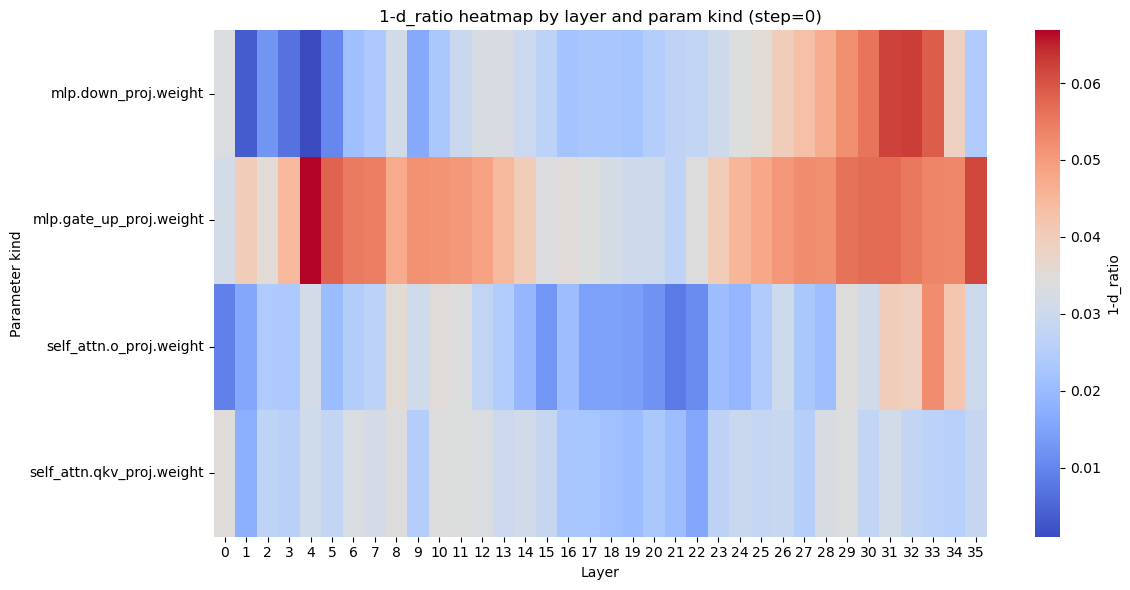

In [70]:
plot_param_heatmap(df_param_norms.query("numel > 10E6"), value_col="1-d_ratio", cmap="coolwarm", )

### GRPO comparison

In [88]:
param_norms_to_df(grpo_df.iloc[78]['param_norms'])

,param_name,delta_norm_sq,shape,numel,shape_str
0,model.layers.34.mlp.down_proj.weight,0.010989,"[2560, 9728]",24903680,2560 x 9728
1,model.layers.19.mlp.down_proj.weight,0.008928,"[2560, 9728]",24903680,2560 x 9728
2,model.layers.18.mlp.down_proj.weight,0.008882,"[2560, 9728]",24903680,2560 x 9728
3,model.layers.21.mlp.up_proj.weight,0.008851,"[9728, 2560]",24903680,9728 x 2560
4,model.layers.20.mlp.down_proj.weight,0.008818,"[2560, 9728]",24903680,2560 x 9728
...,...,...,...,...,...
393,model.layers.30.input_layernorm.weight,0.000000,[2560],2560,2560
394,model.layers.31.input_layernorm.weight,0.000000,[2560],2560,2560
395,model.layers.35.input_layernorm.weight,0.000000,[2560],2560,2560
396,model.layers.1.self_attn.k_norm.weight,0.000000,[128],128,128


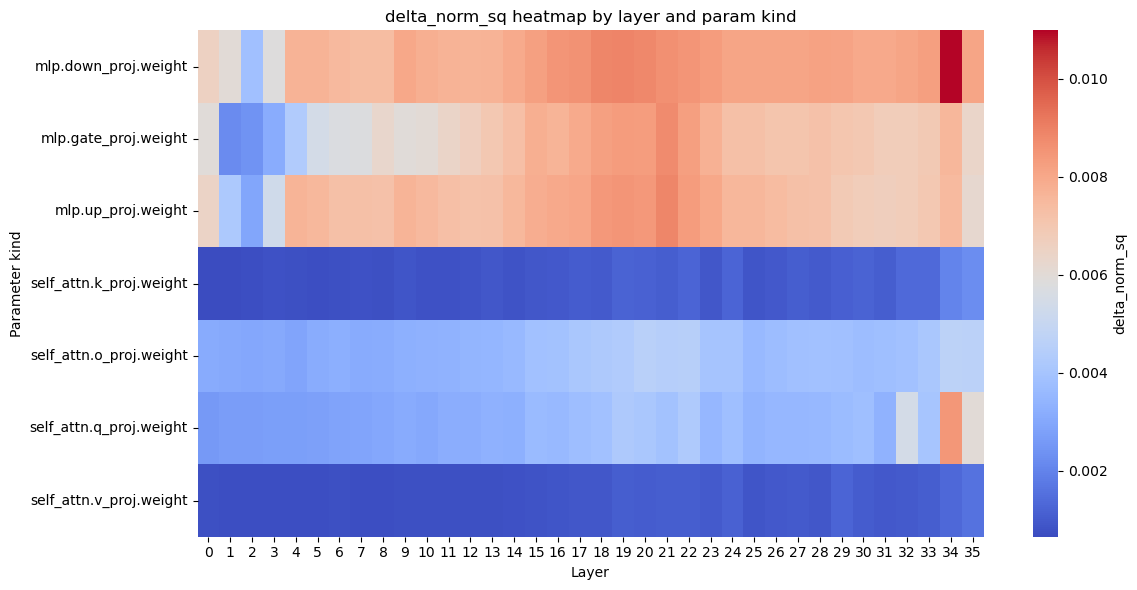

In [105]:
df_param_norms_grpo = add_layer_and_kind_columns(param_norms_to_df(grpo_df.iloc[78]['param_norms']))
df_param_norms_grpo["delta_norm_sq_per_el"] = df_param_norms_grpo["delta_norm_sq"] / df_param_norms_grpo["numel"]
plot_param_heatmap(df_param_norms_grpo.query("numel > 10E5"), value_col="delta_norm_sq", cmap="coolwarm", )

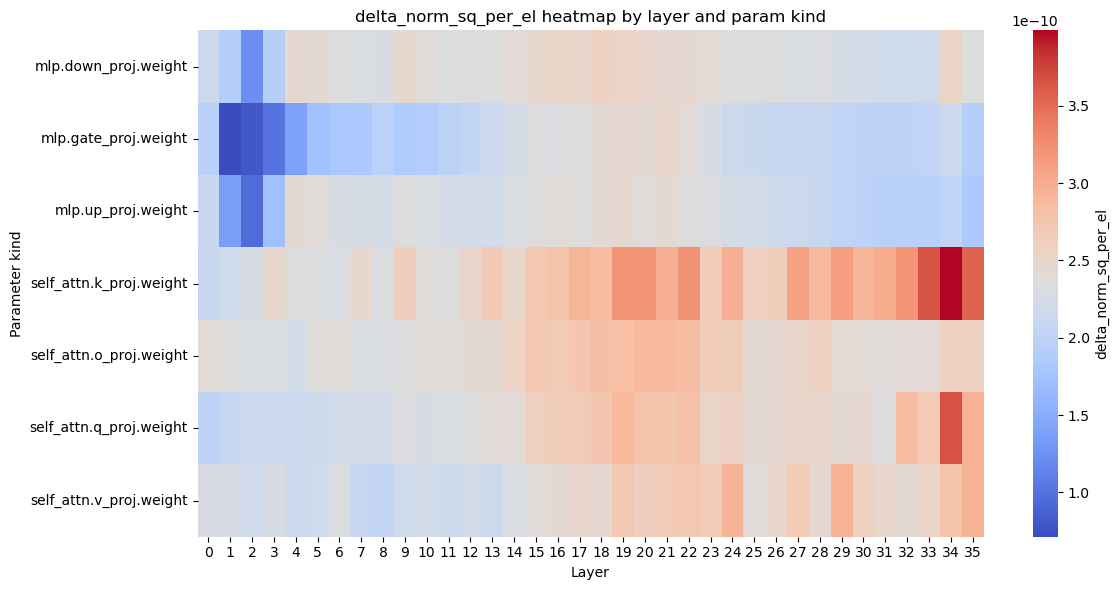

In [108]:
df_param_norms_grpo = add_layer_and_kind_columns(param_norms_to_df(grpo_df.iloc[20]['param_norms']))
df_param_norms_grpo["delta_norm_sq_per_el"] = df_param_norms_grpo["delta_norm_sq"] / df_param_norms_grpo["numel"]
plot_param_heatmap(df_param_norms_grpo.query("numel > 10E5"), value_col="delta_norm_sq_per_el", cmap="coolwarm", )

In [ ]:
param_norms_to_df(grpo_df.iloc[78]['param_norms'])

In [79]:
param_norms_list_to_df(grpo_df.iloc[78]['param_norms'])

""


In [83]:
grpo_df_param_norms = param_norms_list_to_df(grpo_df.iloc[0]['param_norms'])
